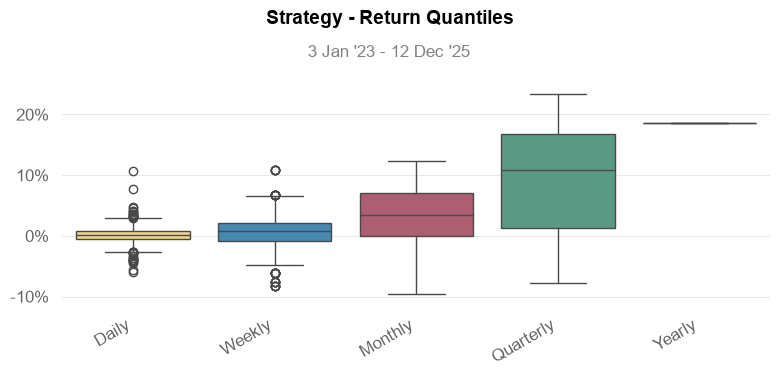

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from pypfopt import EfficientFrontier, risk_models
import quantstats as qs
from tensorflow.keras.regularizers import l2

tickers = ["MSFT", "GOOGL", "NVDA", "JNJ", "AMZN"]
data = yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]

returns_20d = data.pct_change(20).shift(-20)

def sequences(prices_scaled, targets_df, seq_len=30, horizon=20):
    X, y = [], []
    N = len(prices_scaled)

    for i in range(seq_len, N - horizon + 1):
        X.append(prices_scaled[i - seq_len : i])
        y.append(targets_df.iloc[i - 1].values)
    return np.array(X), np.array(y)

train_window = 252 * 3
test_step = 20
seq_len = 30
horizon = 20

weights_records = []
period_dates = []

predicted_monthly_returns = []
actual_monthly_returns = []
actual_daily_series = []

for t in range(train_window, len(data) - test_step, test_step):

    current_date = data.index[t]
    period_dates.append(current_date.strftime('%Y-%m-%d'))

    train_prices = data.iloc[t - train_window : t]
    train_targets = returns_20d.iloc[t - train_window : t]

    scaler = StandardScaler()
    train_prices_scaled = scaler.fit_transform(train_prices)

    X_train, y_train = sequences(
        train_prices_scaled, train_targets, seq_len=seq_len, horizon=horizon
    )

    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(tickers)), return_sequences=False),
        Dropout(0.2),
        #Dense(len(tickers))
        Dense(len(tickers), kernel_regularizer=l2(0.01))
    ])
    model.compile(optimizer="adam", loss="huber")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    last_seq = train_prices_scaled[-seq_len:][np.newaxis, :, :]
    pred_20d_returns = model.predict(last_seq, verbose=0).flatten()

    cov_matrix = risk_models.risk_matrix(train_prices, method="ledoit_wolf")

    pred_annual_returns = pred_20d_returns * 12
    pred_series = pd.Series(pred_annual_returns, index=tickers)

    ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))

    try:
        ef.max_sharpe(risk_free_rate=0.0)
    except Exception:
        ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))
        ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    weights = np.array([cleaned_weights[ticker] for ticker in tickers])
    weights_records.append(weights)

    pred_portfolio_20d = np.sum(pred_20d_returns * weights)
    predicted_monthly_returns.append(pred_portfolio_20d)

    test_actual_prices = data.iloc[t - 1 : t + test_step]
    actual_daily_returns = test_actual_prices.pct_change().dropna()

    port_daily_ret = (actual_daily_returns * weights).sum(axis=1)
    actual_daily_series.append(port_daily_ret)

    actual_portfolio_20d = (1 + port_daily_ret).prod() - 1
    actual_monthly_returns.append(actual_portfolio_20d)

portfolio_returns = pd.concat(actual_daily_series)
portfolio_returns.name = "Clean_LSTM_Portfolio"
portfolio_returns.index = pd.to_datetime(portfolio_returns.index).tz_localize(None)

qs.reports.full(portfolio_returns)

In [2]:
import quantstats as qs

portfolio_returns = pd.concat(actual_daily_series)
portfolio_returns.name = "LSTM_Portfolio"

portfolio_returns.index = pd.to_datetime(portfolio_returns.index).tz_localize(None)

spy = yf.download("SPY", start=portfolio_returns.index[0], end=portfolio_returns.index[-1])["Close"]
spy_returns = spy.pct_change().dropna()
spy_returns.name = "SPY"
spy_returns.index = pd.to_datetime(spy_returns.index).tz_localize(None)

df_returns = pd.concat([portfolio_returns, spy_returns], axis=1).dropna()
port_ret = df_returns["LSTM_Portfolio"]
bench_ret = df_returns["SPY"]

print("\nМетрики портфеля")
qs.extend_pandas()

print(f"CAGR: {qs.stats.cagr(port_ret) * 100:.2f}%")
print(f"Коэффициент Шарпа:         {qs.stats.sharpe(port_ret):.2f}")
print(f"Коэффициент Сортино:       {qs.stats.sortino(port_ret):.2f}")
print(f"Максимальная просадка:     {qs.stats.max_drawdown(port_ret) * 100:.2f}%")
print(f"Винрейт (Доля прибыльных дней): {qs.stats.win_rate(port_ret) * 100:.2f}%")


 Полный HTML-отчет сохранен в файл 'portfolio_report.html'


In [ ]:
# 4. Визуальный сводный отчет (Графики)
qs.plots.snapshot(port_ret, title="LSTM + PyPortfolioOpt Performance", show=True)

# 5. Генерация полного HTML-отчета
qs.reports.html(port_ret, benchmark=bench_ret, output="portfolio_report.html", title="LSTM Portfolio vs S&P 500")
print("\n Полный HTML-отчет сохранен в файл 'portfolio_report.html'")

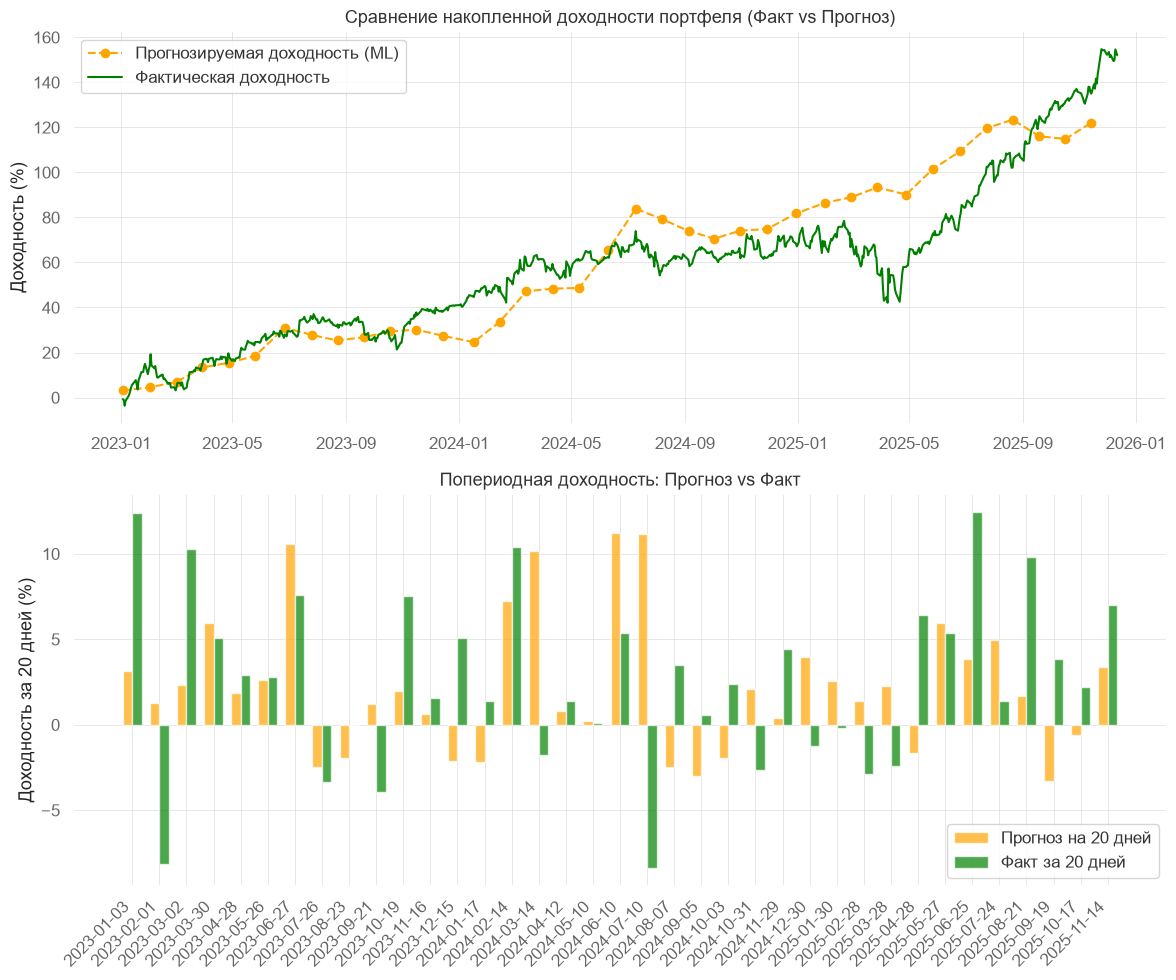

In [3]:
cum_predicted = np.cumprod(1 + np.array(predicted_monthly_returns)) - 1
cum_actual_daily = (1 + portfolio_returns).cumprod() - 1
monthly_dates = pd.to_datetime(period_dates)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Накопленная доходность
axes[0].plot(monthly_dates, cum_predicted * 100, label="Прогнозируемая доходность (ML)", color="orange", linestyle="--", marker="o")
axes[0].plot(cum_actual_daily.index, cum_actual_daily * 100, label="Фактическая доходность", color="green")
axes[0].set_title("Сравнение накопленной доходности портфеля (Факт vs Прогноз)")
axes[0].set_ylabel("Доходность (%)")
axes[0].grid(True)
axes[0].legend()

# График 2: Помесячные доходности (20-дневные интервалы)
x = np.arange(len(period_dates))
width = 0.35

axes[1].bar(x - width/2, np.array(predicted_monthly_returns) * 100, width, label="Прогноз на 20 дней", color="orange", alpha=0.7)
axes[1].bar(x + width/2, np.array(actual_monthly_returns) * 100, width, label="Факт за 20 дней", color="green", alpha=0.7)
axes[1].set_title("Попериодная доходность: Прогноз vs Факт")
axes[1].set_xticks(x)
axes[1].set_xticklabels(period_dates, rotation=45, ha="right")
axes[1].set_ylabel("Доходность за 20 дней (%)")
axes[1].grid(True, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()